<img src="../../../figs/holberton_logo.png" alt="logo" width="500"/>

# Autoencoders

## What is an autoencoder?

Autoencoders are **a type of artificial neural network architecture used in unsupervised machine learning**. 


They consist of an **encoder** and a **decoder** and are primarily designed for dimensionality reduction and feature learning. 

<img src="autoencoders.png" alt="logo" width="700"/>


### Encoder 

The encoder is the first part of the neural network that **compresses and encodes the input data into a lower-dimensional representation (encoding)**. It learns to capture essential features and patterns from the input data.

### Decoder

The decoder is the second part of the neural network that **takes the encoded representation from the encoder and reconstructs the original input data from it**. It aims to produce an output that is as close as possible to the input, effectively "decoding" the information from the encoding.


Consider an example with a **noisy** handwritten digit image:

- **Encoder**: It compresses the input image into a lower-dimensional representation (e.g., 32 numbers) that captures essential features.

- **Decoder**: The decoder takes the encoding and reconstructs an image. It aims to produce a clean version of the original image, removing noise.



## What is latent space?

In the context of autoencoders, the **latent space refers to the compressed representation of input data that is learned by the encoder part of the autoencoder neural network**. It is a **lower-dimensional space where the essential features and patterns of the input data are captured**. 


- **Encoding**: When you feed data into an autoencoder, the encoder component of the network compresses the input data into a fixed-size vector within the latent space. This vector, often referred to as the "encoding" or "latent representation," represents a **compact and abstract form of the input data**.


- **Dimensionality Reduction**: The latent space typically has fewer dimensions than the input data, as the primary purpose of the autoencoder is dimensionality reduction. By reducing the dimensionality, the encoder retains only the most important information from the input.


- **Feature Extraction**: The latent space representation is a feature-rich encoding. It captures meaningful characteristics or features of the input data, making it suitable for tasks like data reconstruction, denoising, or even generating new data samples.


- **Reconstruction**: In autoencoders, the decoder component takes this latent representation and attempts to reconstruct the original input data. The quality of this reconstruction depends on how well the autoencoder has learned to represent the data in the latent space. Ideally, a well-trained autoencoder should be able to recreate input data faithfully from its latent representation.


## What is a bottleneck?

In the context of autoencoders, a `bottleneck` refers to **the narrowest or lowest-dimensional part of the network, where the encoding of the input data is most compressed**. 

It is the layer or vector within the autoencoder architecture that has the fewest neurons or dimensions. The bottleneck's purpose is to **force the network to capture only the most essential features of the input data**, resulting in efficient dimensionality reduction and feature extraction.


## What is a sparse autoencoder?

A sparse autoencoder is a **type of autoencoder neural network that incorporates a sparsity constraint during training**. In a standard autoencoder, the objective is to reconstruct the input data accurately. 


In contrast, a **sparse autoencoder encourages the model to learn a sparse representation of the input data, meaning that only a small subset of neurons or units in the encoding layer is active or has non-zero values for any given input**.


- **Sparsity Constraint**: During training, a penalty term is added to the loss function, encouraging the model to activate only a limited number of neurons in the encoding layer for each input sample. This constraint forces the autoencoder to learn a more compact and informative representation.


- **Feature Selection**: By promoting sparsity, a sparse autoencoder effectively performs feature selection. It learns to identify and emphasize the most relevant features in the input data while suppressing irrelevant or noisy features.


- **Dimensionality Reduction**: Sparsity helps in achieving efficient dimensionality reduction. The encoded representation in a sparse autoencoder is often more concise than that of a standard autoencoder, making it useful for tasks where data compression or feature extraction is essential.


## What is a convolutional autoencoder?

A convolutional autoencoder **is a specific type of autoencoder neural network that is designed for processing and reconstructing data with a grid-like or spatial structure, such as images**. 


It leverages convolutional layers and pooling layers in both the encoder and decoder components to capture and reconstruct spatial patterns effectively. Convolutional autoencoders are particularly well-suited for tasks involving image denoising, image compression, and feature extraction in computer vision applications.


## What is a generative model?

A **generative model is a type of machine learning model designed to generate new data samples that are similar to a given dataset**. These models learn the underlying patterns and structures within the data and can then produce new data points that resemble the training examples. The primary goal of generative models is to capture the probability distribution of the data so that they can generate realistic and coherent samples.

There are several types of generative models, including:


- **Variational Autoencoders (VAEs)**: VAEs are a type of autoencoder that learns to encode data into a latent space and then decode it back into data. They are probabilistic models that focus on capturing the distribution of data points in the latent space, allowing for the generation of new samples.



- **Generative Adversarial Networks (GANs)**: GANs consist of two neural networks, a generator, and a discriminator, that compete with each other during training. The generator aims to create realistic data samples to deceive the discriminator, while the discriminator tries to distinguish between real and generated samples. This adversarial training process results in the generation of high-quality data.


- **Autoregressive Models**: Autoregressive models, like the PixelCNN and PixelRNN, model the conditional probability of each data point based on previous points. They generate data sequentially, making them well-suited for sequences and images.

# Example: Autoencoders

## Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures.

In [7]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "autoencoders"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

A couple utility functions to plot grayscale 28x28 image:

In [9]:
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

## PCA with a linear Autoencoder

Build 3D dataset:

- Generate a 3D dataset using random angles and applies data preprocessing by centering it around the origin


- `m` is the number of data points to generate.


- `w1` and `w2` are weight parameters used in generating the data.


- `noise` represents the amount of random noise to add to the data points.

In [11]:
np.random.seed(4)

def generate_3d_data(m, w1=0.1, w2=0.3, noise=0.1):
    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
    data[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
    data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * np.random.randn(m)
    return data

X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0, keepdims=0)

### Building the Autoencoder

- The **encoder** consists of a single dense layer with `2` units. This layer will reduce the input dimensionality from `3` to `2`, effectively performing dimensionality reduction similar to PCA.



- The **decoder** consists of a single dense layer with 3 units. This layer will take the reduced-dimensional data and attempt to reconstruct the original 3D data.



-  This architecture allows the model to first compress the data using the encoder and then attempt to reconstruct it using the decoder.


- The autoencoder is compiled using `autoencoder.compile`. The loss function is set to `mse`, which stands for `Mean Squared Error`. This loss measures the reconstruction error, indicating how well the autoencoder can reproduce the input data.


- The optimizer used is `Stochastic Gradient Descent (SGD)` with a learning rate of 1.5. SGD is used to update the model's weights during training, and the learning rate controls the step size of these updates

In [13]:
np.random.seed(42)
tf.random.set_seed(42)

encoder = keras.models.Sequential([keras.layers.Dense(2, input_shape=[3])])
decoder = keras.models.Sequential([keras.layers.Dense(3, input_shape=[2])])
autoencoder = keras.models.Sequential([encoder, decoder])

autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1.5))

C:\Users\evisp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
history = autoencoder.fit(X_train, X_train, epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2797  
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0450 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0331 
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0252 
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0169 
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0133 
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0120 


In [17]:
codings = encoder.predict(X_train)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


Saving figure linear_autoencoder_pca_plot


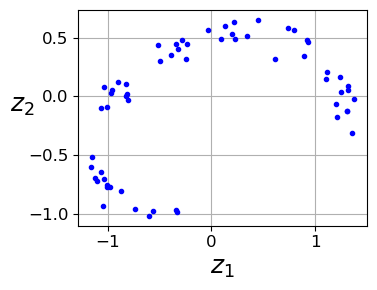

In [19]:
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(True)
save_fig("linear_autoencoder_pca_plot")
plt.show()

## Stacked Autoencoders

Let's use Fashion MNIST:

Fashion MNIST is a dataset comprising `70,000` grayscale images of fashion items, organized into `10` distinct classes, such as T-shirts, trousers, and shoes. Each image is `28x28` pixels in size and serves as a popular benchmark for training and evaluating machine learning and deep learning models. Now, we 

- Load the dataset, scaling the pixel values to a range between `0` and `1`

- Split the dataset into training, validation, and test sets using `X_train`, `y_train` for training, `X_valid`, `y_valid` for validation, and `X_test`, `y_test` for testing.

In [21]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

### Train All Layers

We will build a **Stacked Autoencoder** using TensorFlow and Keras for dimensionality reduction and feature learning on the Fashion MNIST dataset. 

#### Architecture goal: learn a compressed representation of input data for tasks like feature extraction or image denoising.


1. **Encoder**:
    - Two dense layers with `SELU` activation
    - Input shape: `28x28`
    - Output shape: `30`
    
    
2. **Decoder**:
    - Two dense layers with SELU activation (including one for output)
    - Reshapes output to `28x28`
    
    
    
3. Training with `binary cross-entropy` loss



4. `Stochastic Gradient Descent (SGD)` optimizer with learning rate `1.5`



5. `20` training epochs




It sets random seeds for reproducibility, defines an encoder and decoder architecture with specific activation functions, and then combines them to form the stacked autoencoder. The autoencoder is compiled with binary cross-entropy loss and trained on the dataset for 20 epochs using stochastic gradient descent. The primary objective is to learn a compact representation of the input data and improve its reconstruction while minimizing the loss, making it suitable for tasks like image denoising or feature extraction.

Let's build a stacked Autoencoder with 3 hidden layers and 1 output layer (i.e., 2 stacked Autoencoders).

In [23]:
def rounded_accuracy(y_true, y_pred):
    return keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

In [25]:
tf.random.set_seed(42)
np.random.seed(42)

stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu"),
])

stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])

stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=keras.optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])

history = stacked_ae.fit(X_train, X_train, epochs=20,
                         validation_data=(X_valid, X_valid))

C:\Users\evisp\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3798 - rounded_accuracy: 0.8505 - val_loss: 0.3123 - val_rounded_accuracy: 0.9116
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3077 - rounded_accuracy: 0.9130 - val_loss: 0.3058 - val_rounded_accuracy: 0.9121
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2988 - rounded_accuracy: 0.9212 - val_loss: 0.3002 - val_rounded_accuracy: 0.9171
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2941 - rounded_accuracy: 0.9255 - val_loss: 0.2946 - val_rounded_accuracy: 0.9241
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2909 - rounded_accuracy: 0.9284 - val_loss: 0.2906 - val_rounded_accuracy: 0.9308
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2888 - rounded_accuracy: 0.9302 - val_loss: 0.2894 - val_rounded_accuracy: 0.9309
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2872 - rounded_accuracy: 0.9316 - val_loss: 0.2884 - val_rou

### Display Data

This function processes a few test images through the autoencoder and displays the original images and their reconstructions

We visualize the reconstructions produced by a given autoencoder model. It takes as input the model, a set of images (defaulting to the validation set `X_valid`), and the number of images to visualize (defaulting to `5`). 


For each selected image, it uses the autoencoder to generate a reconstruction and then displays both the original image and its reconstruction side by side in a plot. 



This function is useful for assessing how well the autoencoder model is able to capture and reproduce the input data, providing a visual comparison between the original and reconstructed images.

In [22]:
def show_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

1/1 [==============================] - 0s 29ms/step
Saving figure reconstruction_plot


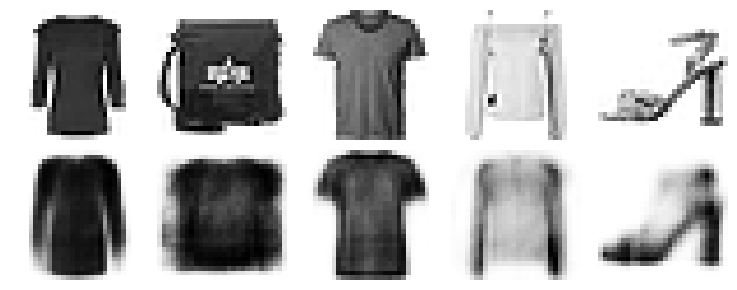

In [23]:
show_reconstructions(stacked_ae)
save_fig("reconstruction_plot")

### Visualizing Fashion MNIST

The goal is to perform dimensionality reduction and visualization using `t-SNE` (t-Distributed Stochastic Neighbor Embedding) on a compressed representation of data. `t-SNE` is a nonlinear dimensionality reduction technique commonly used for visualizing high-dimensional data in a lower-dimensional space, revealing patterns and clusters in the data.


First, a random seed is set for reproducibility. Then, the Stacked Autoencoder (`stacked_encoder`) is used to compress the validation data (`X_valid`). 


The t-SNE algorithm is applied to reduce the dimensionality of the compressed data (`X_valid_compressed`) from a high-dimensional space to a `2D` space while preserving the structure and relationships between data points. 


Finally, the resulting `2D` data is scaled to the range `[0, 1]` for visualization purposes. 

In [14]:
np.random.seed(42)

from sklearn.manifold import TSNE

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)
# Min-Max scaling to normalize the data and bring it into a consistent numerical range for visualization
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())

157/157 [==============================] - 0s 3ms/step


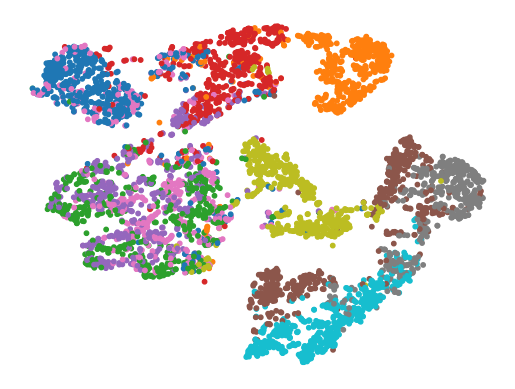

In [15]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.axis("off")
plt.show()

Let's make this diagram a bit prettier. This visualization helps visualize the clustering of fashion items in a lower-dimensional space while maintaining a visual connection to the original images.

Saving figure fashion_mnist_visualization_plot


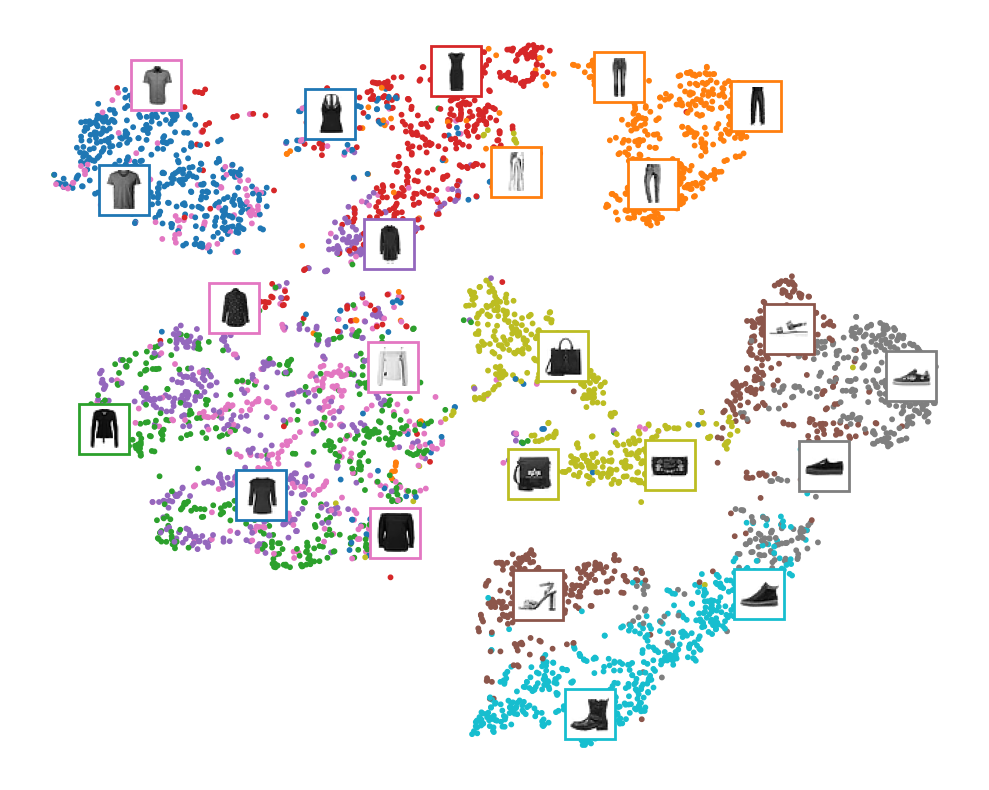

In [16]:
# adapted from https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(X_valid_2D):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)
plt.axis("off")
save_fig("fashion_mnist_visualization_plot")
plt.show()

## Happy Coding